In [555]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, confusion_matrix
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import f1_score
from sklearn.decomposition import PCA
import  pandas as pd
import seaborn as sbn
import matplotlib.pyplot as plt

In [556]:
dataset = load_wine()

In [557]:
scaler = StandardScaler()

x = dataset.data
y = dataset.target

In [558]:
X_train, X_test, y_train, y_test = train_test_split(x, y, test_size=0.2,random_state=42,stratify=y)

In [559]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [560]:
modelo_KNN = make_pipeline(
    PCA(n_components=4),
    KNeighborsClassifier(n_neighbors=3)
)

In [561]:
modelo_KNN.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('kneighborsclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",4
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times 

In [562]:
y_pred_KNN = modelo_KNN.predict(X_test)

In [563]:
print("Real:", y_test)
print("Predito:", y_pred_KNN)

Real: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
Predito: [0 2 0 0 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [564]:
acuracia = accuracy_score(y_test, y_pred_KNN)
cm = confusion_matrix(y_test, y_pred_KNN)
f1 = f1_score(y_test, y_pred_KNN, average="macro")
print(acuracia)
print(cm)
print(f1)

0.9722222222222222
[[12  0  0]
 [ 1 13  0]
 [ 0  0 10]]
0.974320987654321


In [565]:
y_pred_train = modelo_KNN.predict(X_train)
y_pred_test = modelo_KNN.predict(X_test)

print("Treino:", accuracy_score(y_train, y_pred_train))
print("Teste:", accuracy_score(y_test, y_pred_test))

Treino: 0.971830985915493
Teste: 0.9722222222222222


In [566]:
resultados = cross_val_score(modelo_KNN, X_train, y_train, cv=5, scoring="f1_macro")

In [567]:
print(resultados)
print("Média:", resultados.mean())

[0.96963423 0.93160173 0.92951496 0.96451914 0.96658312]
Média: 0.9523706382906812


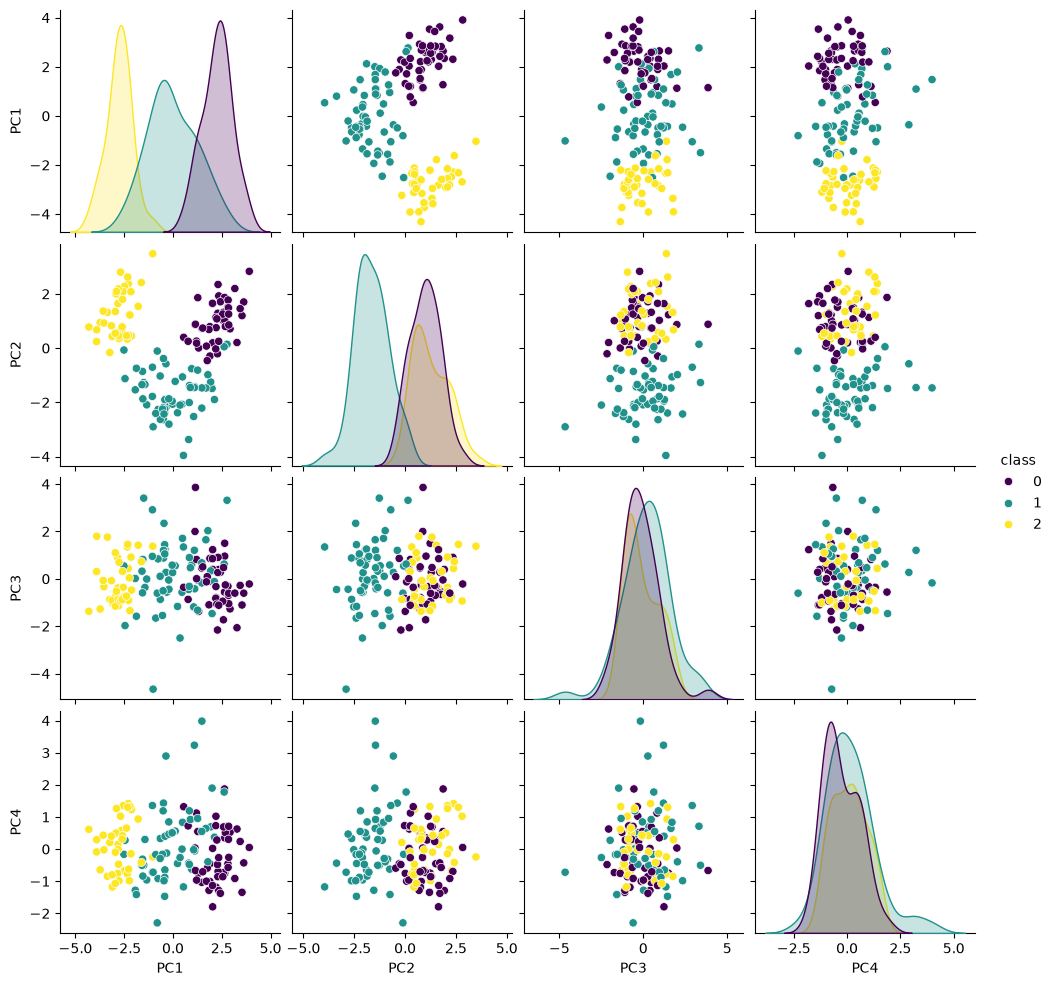

In [568]:
# Aplicar as transformações do pipeline aos dados
X_pca = modelo_KNN[:-1].transform(X_train)

df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2", "PC3","PC4"]
)

df_pca["class"] = y_train

sbn.pairplot(
    df_pca,
    hue="class",
    palette="viridis"
)

plt.show()

In [569]:
pca = modelo_KNN.named_steps["pca"]

print(pca.explained_variance_ratio_)
print(pca.explained_variance_ratio_.sum() * 100)

[0.35792104 0.19270671 0.11019835 0.07272276]
73.35488653902019


-----------------------------------------------------------------------------------------------------------------------------------------------------

In [570]:
modelo_RF = make_pipeline(
    PCA(n_components=5),
    RandomForestClassifier(random_state=42)
)

In [571]:
modelo_RF.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('randomforestclassifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",5
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 time

In [572]:
y_pred_RF = modelo_RF.predict(X_test)

In [573]:
print("Real:", y_test)
print("Predito:", y_pred_RF)

Real: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
Predito: [0 2 0 0 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 1 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [574]:
acuracia = accuracy_score(y_test, y_pred_RF)
cm = confusion_matrix(y_test, y_pred_RF)
f1 = f1_score(y_test, y_pred_RF, average="macro")
print(acuracia)
print(cm)
print(f1)

0.9444444444444444
[[11  1  0]
 [ 1 13  0]
 [ 0  0 10]]
0.9484126984126985


In [575]:
y_pred_train = modelo_RF.predict(X_train)
y_pred_test = modelo_RF.predict(X_test)

print("Treino:", accuracy_score(y_train, y_pred_train))
print("Teste:", accuracy_score(y_test, y_pred_test))

Treino: 1.0
Teste: 0.9444444444444444


In [576]:
resultados = cross_val_score(modelo_RF, X_train, y_train, cv=5, scoring="f1_macro")

In [577]:
print(resultados)
print("Média:", resultados.mean())

[1.         0.90096618 0.96658312 1.         1.        ]
Média: 0.9735098616105482


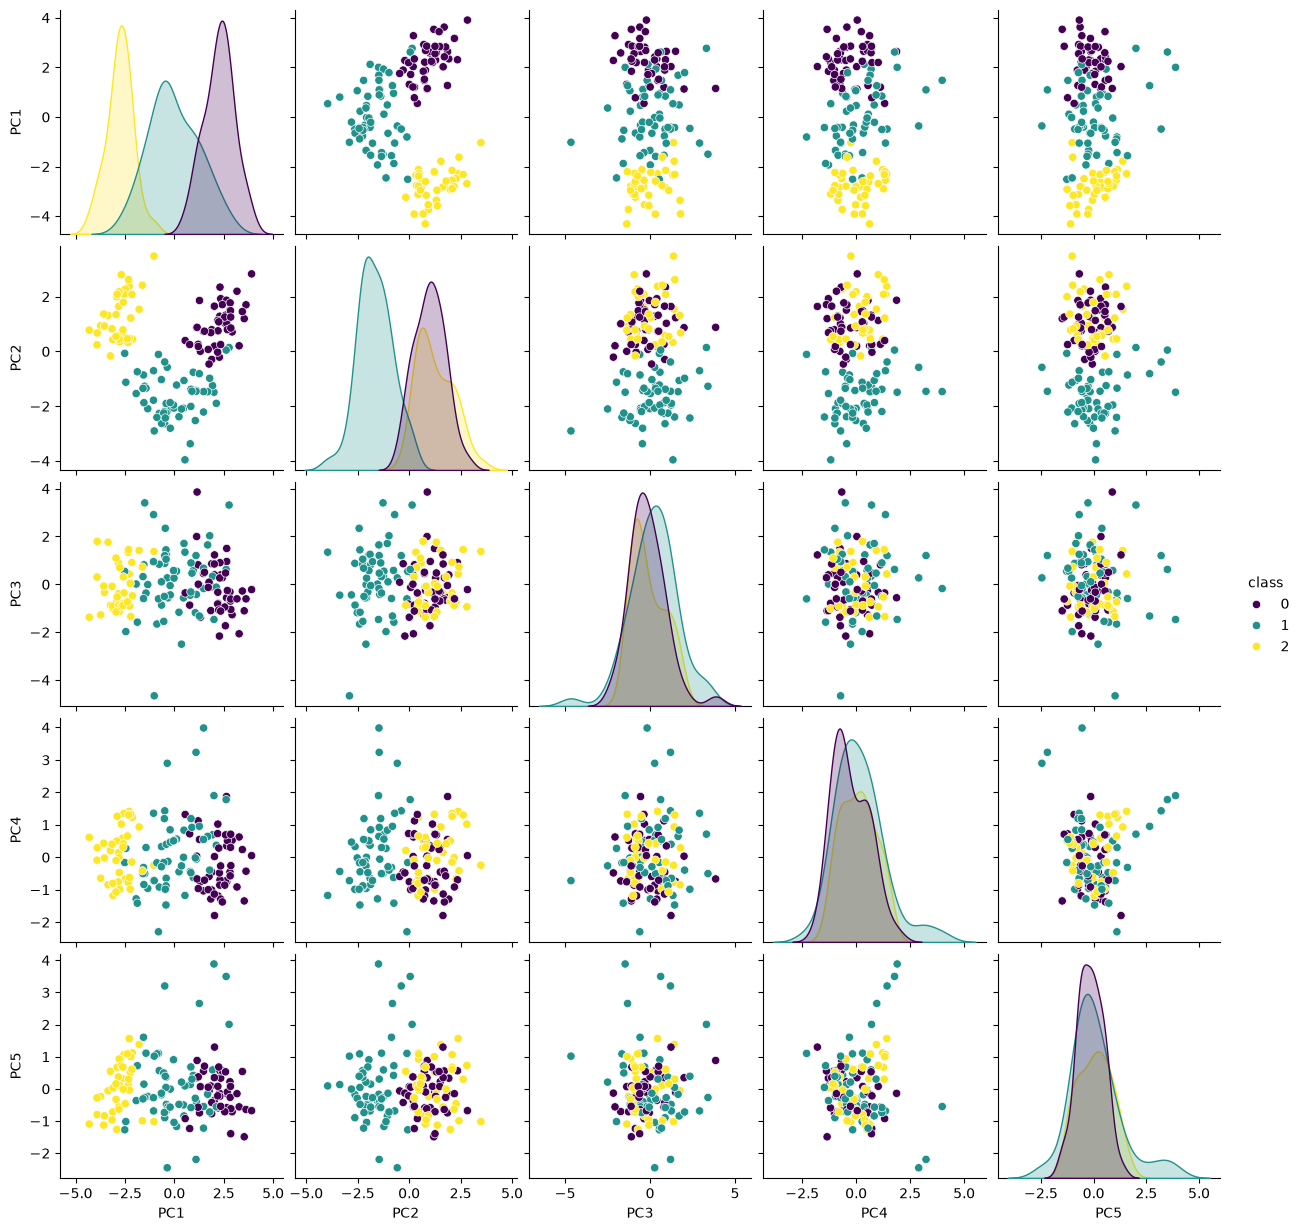

In [578]:
X_pca_rf = modelo_RF[:-1].transform(X_train)

df_pca_rf = pd.DataFrame(
    X_pca_rf,
    columns=["PC1", "PC2", "PC3", "PC4", "PC5"]
)

df_pca_rf["class"] = y_train

sbn.pairplot(
    df_pca_rf,
    hue="class",
    palette="viridis"
)

plt.show()

In [579]:
pca_rf = modelo_RF.named_steps["pca"]

print(pca_rf.explained_variance_ratio_)
print(pca_rf.explained_variance_ratio_.sum() * 100)

[0.35792104 0.19270671 0.11019835 0.07272276 0.06721919]
80.07680555289933


-----------------------------------------------------------------------------------------------------------------------------------------------------

In [580]:
modelo = make_pipeline(
    PCA(n_components=3),
    LogisticRegression(random_state=42, max_iter=2000)
)

In [581]:
modelo.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('pca', ...), ('logisticregression', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[int64](3,)","[0,1,2]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,13
,"n_components n_components: int, float or 'mle', default=NoneNumber of components to keep.if n_components is not set all components are kept:: n_components == min(n_samples, n_features)If ``n_components == 'mle'`` and ``svd_solver == 'full'``, Minka'sMLE is used to guess the dimension. Use of ``n_components == 'mle'``will interpret ``svd_solver == 'auto'`` as ``svd_solver == 'full'``.If ``0 < n_components < 1`` and ``svd_solver == 'full'``, select thenumber of components such that the amount of variance that needs to beexplained is greater than the percentage specified by n_components.If ``svd_solver == 'arpack'``, the number of components must bestrictly less than the minimum of n_features and n_samples.Hence, the None case results in:: n_components == min(n_samples, n_features) - 1",3
,"copy copy: bool, default=TrueIf False, data passed to fit are overwritten and runningfit(X).transform(X) will not yield the expected results,use fit_transform(X) instead.",True
,"whiten whiten: bool, default=FalseWhen True (False by default) the `components_` vectors are multipliedby the square root of n_samples and then divided by the singular valuesto ensure uncorrelated outputs with unit component-wise variances.Whitening will remove some information from the transformed signal(the relative variance scales of the components) but can sometimeimprove the predictive accuracy of the downstream estimators bymaking their data respect some hard-wired assumptions.",False
,"svd_solver svd_solver: {'auto', 'full', 'covariance_eigh', 'arpack', 'randomized'}, default='auto'""auto"" : The solver is selected by a default 'auto' policy is based on `X.shape` and `n_components`: if the input data has fewer than 1000 features and more than 10 times as

In [582]:
y_pred = modelo.predict(X_test)

In [583]:
print("Real:", y_test)
print("Predito:", y_pred)

Real: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]
Predito: [0 2 0 1 1 0 0 1 1 2 1 2 0 2 0 1 1 0 1 0 1 1 0 0 1 1 0 2 1 2 0 2 1 2 2 2]


In [584]:
acuracia = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
f1 = f1_score(y_test, y_pred, average="macro")
print(acuracia)
print(cm)
print(f1)

1.0
[[12  0  0]
 [ 0 14  0]
 [ 0  0 10]]
1.0


In [585]:
y_pred_train = modelo.predict(X_train)
y_pred_test = modelo.predict(X_test)

print("Treino:", accuracy_score(y_train, y_pred_train))
print("Teste:", accuracy_score(y_test, y_pred_test))

Treino: 0.9647887323943662
Teste: 1.0


In [586]:
resultados = cross_val_score(modelo, X_train, y_train, cv=5, scoring="f1_macro")

In [587]:
print(resultados)
print("Média:", resultados.mean())

[0.96912281 0.90096618 0.96658312 1.         1.        ]
Média: 0.9673344230140568


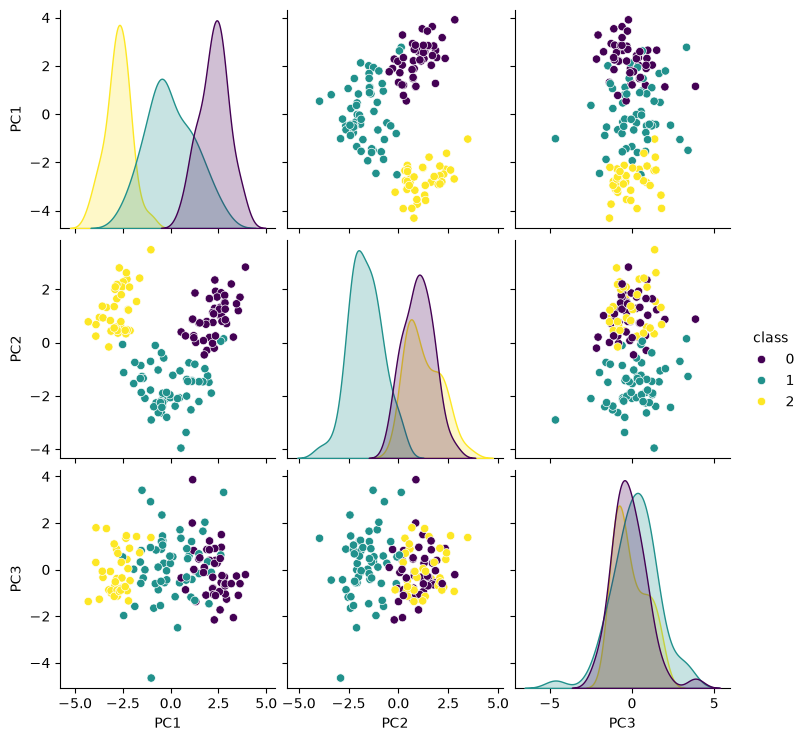

In [589]:

# Aplicar as transformações do pipeline da Regressão Logística
X_pca_lr = modelo[:-1].transform(X_train)

# Criar o DataFrame com os 5 componentes
df_pca_lr = pd.DataFrame(
    X_pca_lr,
    columns=["PC1", "PC2", "PC3"]
)

# Adicionar as classes reais dos vinhos
df_pca_lr["class"] = y_train

# Plotar os gráficos
sbn.pairplot(
    df_pca_lr,
    hue="class",
    palette="viridis"
)

plt.show()